# Lab Task:

####  Model: Build and train a custom CNN with the following structure:

Conv2D(64 filters, (3×3), ReLU) → BatchNormalization → MaxPooling2D(2×2)

Conv2D(128 filters, (3×3), ReLU) → BatchNormalization → MaxPooling2D(2×2)

Conv2D(256 filters, (3×3), ReLU) → Dropout(0.3) → MaxPooling2D(2×2)

Flatten → Dense(256, ReLU) → Dropout(0.5) → Dense(1, Sigmoid)

#### Dataset: Use only two classes:

from the last lab tasks

#### Compile with: binary_crossentropy loss and adam optimizer.

#### Train and evaluate the model.

In [1]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

In [2]:
checkpoints = r'D:\8th Semester\Machine Learning Lab\\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'

In [3]:
train_dir = r'D:\8th Semester\Machine Learning Lab\Computer vision\train'
validation_dir = r'D:\8th Semester\Machine Learning Lab\Computer vision\validation'
test_dir = r'D:\8th Semester\Machine Learning Lab\Computer vision\test'

In [4]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',input_shape=(256, 256, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(4,activation='softmax'))

In [5]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 127, 127, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 62, 62, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 30, 30, 128)       0

In [6]:
model.compile(loss='categorical_crossentropy', optimizer=optimizers.RMSprop(lr=1e-4), metrics=['acc'])

In [7]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=32,class_mode='categorical')
validation_generator = test_datagen.flow_from_directory(validation_dir,target_size=(256, 256),batch_size=32,class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


In [8]:
EpochCheckpoint = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
callbacks = [EpochCheckpoint]

In [9]:
step_size_train = train_generator.n//train_generator.batch_size

model_history = model.fit(train_generator,
                    validation_data =validation_generator,
                   steps_per_epoch=step_size_train,
                   epochs=5,
                    callbacks=callbacks)

Epoch 1/5



50/50 [==============================] - ETA: 0s - loss: 1.3258 - acc: 0.4494
Epoch 1: val_loss improved from inf to 0.85244, saving model to D:\8th Semester\Machine Learning Lab\E1-cp-0001-loss0.85.h5
50/50 [==============================] - 119s 2s/step - loss: 1.3258 - acc: 0.4494 - val_loss: 0.8524 - val_acc: 0.5079


c:\Users\Shafiq\.conda\envs\DSP\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 2/5
50/50 [==============================] - ETA: 0s - loss: 0.8887 - acc: 0.5275
Epoch 2: val_loss improved from 0.85244 to 0.82054, saving model to D:\8th Semester\Machine Learning Lab\E1-cp-0002-loss0.82.h5
50/50 [==============================] - 119s 2s/step - loss: 0.8887 - acc: 0.5275 - val_loss: 0.8205 - val_acc: 0.5635
Epoch 3/5
50/50 [==============================] - ETA: 0s - loss: 0.8943 - acc: 0.5431
Epoch 3: val_loss improved from 0.82054 to 0.78416, saving model to D:\8th Semester\Machine Learning Lab\E1-cp-0003-loss0.78.h5
50/50 [==============================] - 134s 3s/step - loss: 0.8943 - acc: 0.5431 - val_loss: 0.7842 - val_acc: 0.6310
Epoch 4/5
50/50 [==============================] - ETA: 0s - loss: 0.7872 - acc: 0.6525
Epoch 4: val_loss improved from 0.78416 to 0.75485, saving model to D:\8th Semester\Machine Learning Lab\E1-cp-0004-loss0.75.h5
50/50 [==============================] - 100s 2s/step - loss: 0.7872 - acc: 0.6525 - val_loss: 0.7548 - val_acc:

In [10]:
model_history.history

{'loss': [1.3257784843444824,
  0.8887266516685486,
  0.8942826986312866,
  0.7871946692466736,
  0.5757371783256531],
 'acc': [0.4493750035762787,
  0.5274999737739563,
  0.5431249737739563,
  0.6524999737739563,
  0.7437499761581421],
 'val_loss': [0.8524405360221863,
  0.8205435872077942,
  0.7841590046882629,
  0.7548475861549377,
  0.9444659948348999],
 'val_acc': [0.5079365372657776,
  0.5634920597076416,
  0.6309523582458496,
  0.6944444179534912,
  0.6428571343421936]}

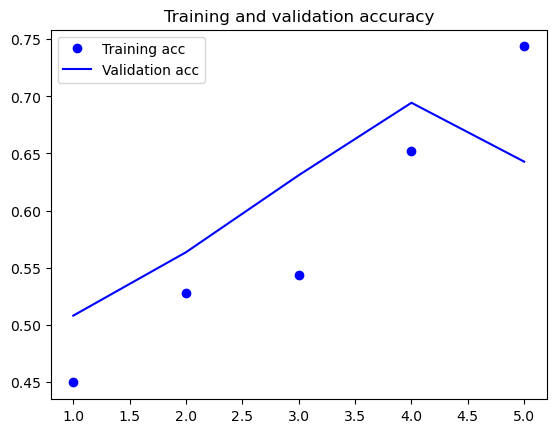

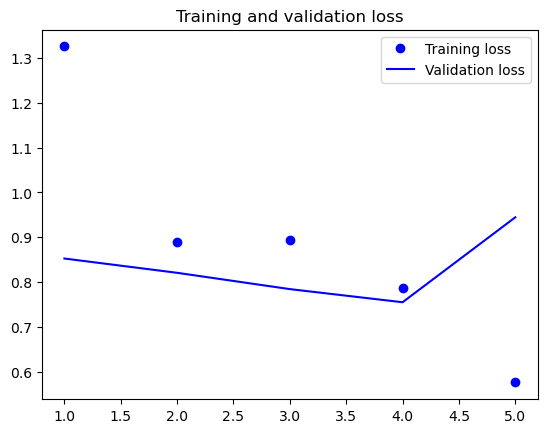

<Figure size 640x480 with 0 Axes>

In [13]:
acc = model_history.history['acc']
val_acc = model_history.history['val_acc']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()
plt.savefig(r'D:\8th Semester\Machine Learning Lab\Computer vision.png')

In [19]:
model.save(r'D:\8th Semester\Machine Learning Lab\Computer vision\E1-cp-0012-loss0.21.h5')

c:\Users\Shafiq\.conda\envs\DSP\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Found 200 images belonging to 4 classes.


7/7 [==============================] - 3s 341ms/step


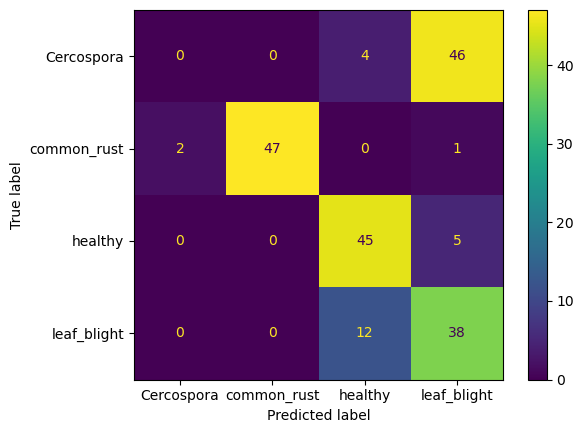

<Figure size 640x480 with 0 Axes>

In [ ]:
#model = load_model(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\model_lab11.h5')
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(256, 256), batch_size=32, shuffle=False, class_mode='categorical')
label=test_generator.labels
preds=model.predict(test_generator)
pred = np.argmax(preds, axis = 1)
cm = confusion_matrix(label, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  display_labels=['Cercospora', 'common_rust','healthy', 'leaf_blight'])
disp.plot()
plt.show()
plt.savefig(r'D:\8th Semester\Machine Learning Lab\Computer vision.jpg')

In [21]:
print(classification_report(label, pred, target_names=['Cercospora', 'common_rust','healthy', 'leaf_blight']))

              precision    recall  f1-score   support

  Cercospora       0.00      0.00      0.00        50
 common_rust       1.00      0.94      0.97        50
     healthy       0.74      0.90      0.81        50
 leaf_blight       0.42      0.76      0.54        50

    accuracy                           0.65       200
   macro avg       0.54      0.65      0.58       200
weighted avg       0.54      0.65      0.58       200

